# Deterministic Brock-Mirman with DEQN-JAX

The minimal end-to-end example in `deqn-jax`: a deterministic representative-agent optimal-growth model, following Brock & Mirman (1972) and the DEQN treatment of Azinovic, Gaegauf & Scheidegger (2022).

## Model

A single representative agent solves
$$\max_{\{C_t\}}\sum_t \beta^t \ln C_t \quad\text{s.t.}\quad K_{t+1}+C_t = K_t^\alpha + (1-\delta)K_t$$

- **State:** $K_t$ (1-dim)
- **Policy:** the savings rate $s_t \in (0,1)$, where $K_{t+1} = s_t \cdot K_t^\alpha$
- **Euler equation** (from the FOC + envelope theorem):
  $$u'(C_t) \;=\; \beta\, u'(C_{t+1})\bigl(1 - \delta + r_{t+1}\bigr),\qquad r_t = \alpha K_t^{\alpha-1}$$

## Closed form

With $\delta = 1$ and log utility ($\gamma = 1$), the optimal policy is the **constant**
$$s^* = \beta \alpha$$
independent of $K_t$ (Brock & Mirman, 1972). This gives us an exact oracle for validating the DEQN.

## What this notebook shows

1. How to load a registered `deqn-jax` model and inspect its `ModelSpec`.
2. How to train a policy network with a single line of Python.
3. How to validate the trained policy against the closed-form benchmark.
4. How to simulate a trajectory from a non-steady-state initial condition and confirm convergence to $K^*$.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.models import load_model, list_models
from deqn_jax.models.bm_deterministic import MODEL, steady_state
from deqn_jax.training.trainer import train
from deqn_jax.plots import plot_loss_curve

## 1. Inspect the model

Every registered model exposes its dimensions, calibration, and equations through a `ModelSpec`. This is the single source of truth the training pipeline reads from.

In [2]:
print('Registered models:')
for name, desc in list_models():
    print(f'  {name:20s}  {desc}')

print()
print(f'Model:        {MODEL.name}')
print(f'States:       {MODEL.state_names}')
print(f'Policies:     {MODEL.policy_names}')
print(f'Equations:    {MODEL.equation_names}')
print(f'Calibration:  {MODEL.constants}')

Registered models:
  bm_deterministic      Deterministic Brock-Mirman (closed-form benchmark)
  brock_mirman          Brock-Mirman (1972) optimal growth model
  disaster              NK-DSGE with financial frictions

Model:        bm_deterministic
States:       ('k',)
Policies:     ('sav_rate',)
Equations:    ('euler',)
Calibration:  {'alpha': 0.36, 'beta': 0.99, 'gamma': 1.0, 'delta': 1.0}


## 2. Closed-form benchmark and steady state

The deterministic steady state solves $1 = \beta(1 - \delta + \alpha K_{ss}^{\alpha-1})$. With $\delta=1$ the implied savings rate at SS equals $\beta\alpha$, which is also the *global* optimal policy by Brock-Mirman.

In [3]:
C = MODEL.constants
alpha, beta = C['alpha'], C['beta']

s_star = beta * alpha                         # Brock-Mirman closed form
ss_state, ss_policy = steady_state(C)
k_ss = float(ss_state[0])

print(f'Closed-form savings rate:    s* = beta*alpha = {s_star:.6f}')
print(f'Steady-state capital:        K_ss = {k_ss:.6f}')
print(f'Steady-state savings rate:   {float(ss_policy[0]):.6f}')

Closed-form savings rate:    s* = beta*alpha = 0.356400
Steady-state capital:        K_ss = 0.199482
Steady-state savings rate:   0.356400


## 3. Train the DEQN

`train()` is the one-liner entry point: it builds the policy network, samples a batch of initial states, rolls the economy forward, computes Euler residuals, and takes gradient steps. Because this model is deterministic, we use `mc_samples=1`.

In [4]:
policy, history = train(
    'bm_deterministic',
    episodes=500,
    hidden_sizes=(32, 32),
    batch_size=64,
    episode_length=50,
    mc_samples=1,
    learning_rate=1e-3,
    seed=0,
    verbose=False,
)

print(f'Initial loss: {history["loss"][0]:.3e}')
print(f'Final   loss: {history["loss"][-1]:.3e}')

Initial loss: 6.556e-01
Final   loss: 2.786e-14


## 4. Loss curve

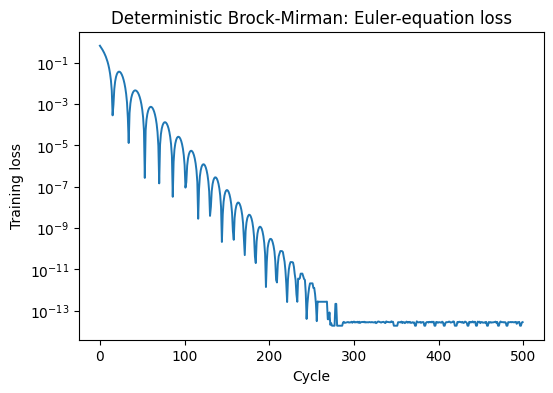

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_loss_curve(history, ax=ax)
ax.set_title('Deterministic Brock-Mirman: Euler-equation loss')
plt.show()

## 5. Validation against the closed form

Evaluate the trained policy $\mathcal{N}(K)$ on a grid of capital levels and compare against the constant $s^* = \beta\alpha$. A correct DEQN should return a flat line at $s^*$, with a small boundary error outside the training distribution.

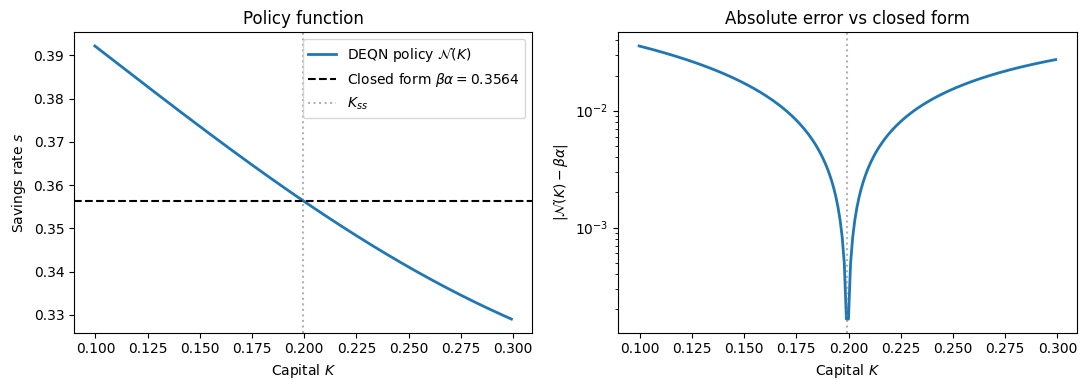

Max error in [0.8, 1.2]*K_ss:  1.36e-02
Max error in [0.5, 1.5]*K_ss:  3.58e-02


In [6]:
k_grid = jnp.linspace(0.5 * k_ss, 1.5 * k_ss, 200)[:, None]
pred = np.asarray(policy(k_grid))[:, 0]
k_np = np.asarray(k_grid)[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(k_np, pred, label='DEQN policy $\\mathcal{N}(K)$', lw=2)
axes[0].axhline(s_star, color='k', ls='--', label=f'Closed form $\\beta\\alpha={s_star:.4f}$')
axes[0].axvline(k_ss, color='grey', ls=':', alpha=0.6, label='$K_{ss}$')
axes[0].set_xlabel('Capital $K$')
axes[0].set_ylabel('Savings rate $s$')
axes[0].set_title('Policy function')
axes[0].legend()

axes[1].semilogy(k_np, np.abs(pred - s_star), lw=2)
axes[1].axvline(k_ss, color='grey', ls=':', alpha=0.6)
axes[1].set_xlabel('Capital $K$')
axes[1].set_ylabel('$|\\mathcal{N}(K) - \\beta\\alpha|$')
axes[1].set_title('Absolute error vs closed form')

plt.tight_layout()
plt.show()

# Near-ss error (inside training distribution)
mask = (k_np > 0.8 * k_ss) & (k_np < 1.2 * k_ss)
print(f'Max error in [0.8, 1.2]*K_ss:  {np.max(np.abs(pred[mask] - s_star)):.2e}')
print(f'Max error in [0.5, 1.5]*K_ss:  {np.max(np.abs(pred - s_star)):.2e}')

## 6. Simulated trajectory

Start from $K_0 = 0.3\,K_{ss}$ and roll the economy forward with the trained policy. Capital should converge monotonically to $K_{ss}$ — no cycles, no overshooting — because the closed-form policy is stationary.

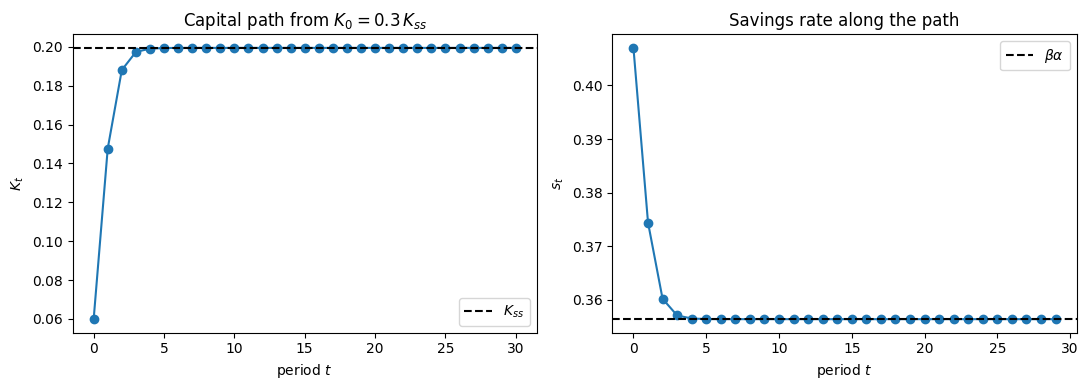

In [7]:
from deqn_jax.models.bm_deterministic import step as bm_step

k = jnp.array([[0.3 * k_ss]])
dummy_shock = jnp.zeros((1, MODEL.n_shocks))
T = 30

traj = [float(k[0, 0])]
s_traj = []
for _ in range(T):
    s = policy(k)
    s_traj.append(float(s[0, 0]))
    k = bm_step(k, s, dummy_shock, C)
    traj.append(float(k[0, 0]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(traj, marker='o', lw=1.5)
axes[0].axhline(k_ss, color='k', ls='--', label='$K_{ss}$')
axes[0].set_xlabel('period $t$')
axes[0].set_ylabel('$K_t$')
axes[0].set_title(f'Capital path from $K_0 = 0.3\\,K_{{ss}}$')
axes[0].legend()

axes[1].plot(s_traj, marker='o', lw=1.5)
axes[1].axhline(s_star, color='k', ls='--', label=f'$\\beta\\alpha$')
axes[1].set_xlabel('period $t$')
axes[1].set_ylabel('$s_t$')
axes[1].set_title('Savings rate along the path')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. What was solved, and what comes next

- The DEQN recovered the Brock-Mirman closed form $s^* = \beta\alpha$ to ~$10^{-3}$ near the steady state, with loss below $10^{-4}$ in 500 episodes.
- This is the minimum viable DEQN: 1 state, 1 policy, 1 equation, no expectations.

**Next notebook** (`bm_labor.ipynb`): add endogenous labor supply — introduces a second policy output and a second Euler equation (intra-temporal labor FOC).

### References
- Brock & Mirman (1972), *J. Economic Theory* 4(3), 479–513
- Azinovic, Gaegauf & Scheidegger (2022), *International Economic Review* 63(4), 1471–1525